# PSO-SVR 超参数优化

使用 **scikit-opt 的 PSO**，以 SVR 的交叉验证误差（CV Loss）为适应度函数，自动搜索最佳超参数 $C$、$\gamma$、$\epsilon$。

## 1. 环境与数据准备

In [16]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer
from sko.PSO import PSO

# 路径兼容：从项目根目录或 week2/week3 启动
_cwd = os.getcwd()
_root = os.path.dirname(_cwd) if os.path.basename(_cwd) in ('week2', 'week3') else _cwd
sys.path.insert(0, os.path.join(_root, 'week2'))
from data import GEFCom2014

In [17]:
RANDOM_SEED = 42
D_NUM = 24
H_NUM = 24
CV_FOLDS = 5

SEARCH_SPACE = {
    'C': np.exp(np.linspace(np.log(1), np.log(100), 16)),
    'gamma': np.array([0.05, 0.1, 0.2, 0.4]),
    'epsilon': np.logspace(-4, -2, 4),
}

PSO_CONFIG = {
    'n_particles': 20,
    'max_iter': 25,
    'w': 0.7,
    'c1': 1.5,
    'c2': 1.5,
}

np.random.seed(RANDOM_SEED)
cv_splitter = TimeSeriesSplit(n_splits=CV_FOLDS)

gefcom2014 = GEFCom2014()
X_tr_3d, y_train = gefcom2014.get_slided_dataset(d_num=D_NUM, h_num=H_NUM, is_train=True)
X_te_3d, y_test = gefcom2014.get_slided_dataset(d_num=D_NUM, h_num=H_NUM, is_train=False)

X_train = X_tr_3d.reshape(len(X_tr_3d), -1)
X_test = X_te_3d.reshape(len(X_te_3d), -1)

# 使用单步数据训练 SVR（与 Iterated 策略一致）
X_tr_iter, y_tr_iter = gefcom2014.get_slided_dataset(d_num=D_NUM, h_num=1, is_train=True)
X_tr_flat = X_tr_iter.reshape(len(X_tr_iter), -1)
y_tr_flat = y_tr_iter[:, 0]

print(f'训练集: {X_tr_flat.shape}, 目标: {y_tr_flat.shape}')
print(f'测试集: {X_test.shape}, {y_test.shape}')
print(f'PSO 随机种子: {RANDOM_SEED}, 时间序列交叉验证折数: {CV_FOLDS}')

训练集: (645, 24), 目标: (645,)
测试集: (284, 24), (284, 24)
PSO 随机种子: 42, 时间序列交叉验证折数: 5


## 2. 适应度函数与搜索规范

将 SVR 的 **CV Loss** 作为 PSO 的适应度，目标为最小化。这里采用 `scikit-opt` 的连续 PSO，并做一个很轻的离散化包装：

- 使用 `TimeSeriesSplit` 做时间序列交叉验证，避免未来信息泄漏
- PSO 在连续空间搜索，评估时再四舍五入到离散超参数索引
- 对重复出现的参数组合启用缓存，减少重复训练
- 将搜索结果统一保存为结构化对象，便于后续画图和评估

In [18]:
def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


rmse_scorer = make_scorer(rmse_score, greater_is_better=False)
fitness_cache = {}

LOWER_BOUNDS = np.zeros(3, dtype=float)
UPPER_BOUNDS = np.array([
    len(SEARCH_SPACE['C']) - 1,
    len(SEARCH_SPACE['gamma']) - 1,
    len(SEARCH_SPACE['epsilon']) - 1,
], dtype=float)


def decode_particle(position):
    """把连续粒子位置映射到离散超参数。"""
    index = np.clip(np.rint(np.asarray(position)).astype(int), LOWER_BOUNDS.astype(int), UPPER_BOUNDS.astype(int))
    params = {
        'C': float(SEARCH_SPACE['C'][index[0]]),
        'gamma': float(SEARCH_SPACE['gamma'][index[1]]),
        'epsilon': float(SEARCH_SPACE['epsilon'][index[2]]),
    }
    return index, params


def fitness_svr_cv(position, stats):
    """scikit-opt 的目标函数：内部再离散化到真实超参数。"""
    index, params = decode_particle(position)
    cache_key = tuple(index.tolist())
    stats['n_evaluations'] += 1

    if cache_key not in fitness_cache:
        model = SVR(
            kernel='rbf',
            C=params['C'],
            gamma=params['gamma'],
            epsilon=params['epsilon'],
        )
        scores = cross_val_score(
            model,
            X_tr_flat,
            y_tr_flat,
            cv=cv_splitter,
            scoring=rmse_scorer,
            n_jobs=1,
        )
        fitness_cache[cache_key] = -float(np.mean(scores))

    return fitness_cache[cache_key]


def run_pso_search():
    """使用 scikit-opt 执行 PSO 搜索。"""
    np.random.seed(RANDOM_SEED)
    fitness_cache.clear()
    stats = {'n_evaluations': 0}

    pso = PSO(
        func=lambda x: fitness_svr_cv(x, stats),
        n_dim=3,
        pop=PSO_CONFIG['n_particles'],
        max_iter=PSO_CONFIG['max_iter'],
        lb=LOWER_BOUNDS,
        ub=UPPER_BOUNDS,
        w=PSO_CONFIG['w'],
        c1=PSO_CONFIG['c1'],
        c2=PSO_CONFIG['c2'],
    )
    pso.run()

    best_position = np.asarray(pso.gbest_x, dtype=float)
    best_idx, best_params = decode_particle(best_position)
    gbest_y_hist = np.asarray(pso.gbest_y_hist, dtype=float).reshape(-1)

    return {
        'optimizer': pso,
        'best_position': best_position,
        'best_idx': best_idx,
        'best_params': best_params,
        'best_cv_rmse': float(np.asarray(pso.gbest_y).item()),
        'gbest_y_hist': gbest_y_hist,
        'n_evaluations': stats['n_evaluations'],
        'n_unique_evaluations': len(fitness_cache),
    }

## 3. PSO 寻优

这里直接使用 `scikit-opt` 的 `PSO`，流程压缩为 4 步：

1. 设置搜索边界和 PSO 参数
2. 在目标函数里把连续位置映射到离散超参数
3. 调用 `pso.run()` 完成搜索
4. 读取最优参数和收敛曲线

In [19]:
search_result = run_pso_search()
pso = search_result['optimizer']
gbest_y_hist = search_result['gbest_y_hist']
best_idx = search_result['best_idx']
best_params = search_result['best_params']
best_C = best_params['C']
best_gamma = best_params['gamma']
best_epsilon = best_params['epsilon']

print('=' * 60)
print('PSO 搜索结果（scikit-opt）')
print('=' * 60)
print(
    f"PSO 配置: n_particles={PSO_CONFIG['n_particles']}, "
    f"max_iter={PSO_CONFIG['max_iter']}, w={PSO_CONFIG['w']}, "
    f"c1={PSO_CONFIG['c1']}, c2={PSO_CONFIG['c2']}"
)
print(f'最优索引: {best_idx.tolist()}')
print(f'最优超参数: C={best_C:.4f}, gamma={best_gamma:.4f}, epsilon={best_epsilon:.6f}')
print(f"最优 CV RMSE: {search_result['best_cv_rmse']:.6f}")
print(f"总评估次数: {search_result['n_evaluations']}")
print(f"唯一参数组合数: {search_result['n_unique_evaluations']}")

PSO 搜索结果（scikit-opt）
PSO 配置: n_particles=20, max_iter=25, w=0.7, c1=1.5, c2=1.5
最优索引: [15, 0, 1]
最优超参数: C=100.0000, gamma=0.0500, epsilon=0.000464
最优 CV RMSE: 0.028051
总评估次数: 520
唯一参数组合数: 54


## 4. 收敛曲线（Fitness vs. Iteration）

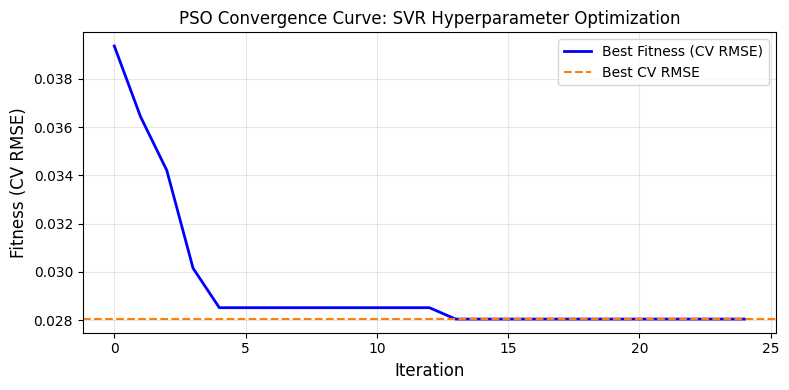

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(gbest_y_hist, 'b-', linewidth=2, label='Best Fitness (CV RMSE)')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Fitness (CV RMSE)', fontsize=12)
plt.title('PSO Convergence Curve: SVR Hyperparameter Optimization', fontsize=12)
plt.axhline(search_result['best_cv_rmse'], color='C1', linestyle='--', linewidth=1.5, label='Best CV RMSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 优化前后 RMSE 对比

In [21]:
def predict_iterated(model, X_test_raw, H_NUM):
    """Iterated 策略：单步模型迭代预测"""
    y_pred = np.zeros((len(X_test_raw), H_NUM))
    for i in range(len(X_test_raw)):
        window = X_test_raw[i].copy()
        for h in range(H_NUM):
            x_in = window.reshape(1, -1)
            pred = model.predict(x_in)[0]
            y_pred[i, h] = pred
            window = np.concatenate([window[1:], [pred]])
    return y_pred

# 原始超参数（与 week2 默认一致）
svr_before = SVR(kernel='rbf', C=10, epsilon=0.01)
svr_before.fit(X_tr_flat, y_tr_flat)

# PSO 优化后的超参数
svr_after = SVR(kernel='rbf', C=best_C, gamma=best_gamma, epsilon=best_epsilon)
svr_after.fit(X_tr_flat, y_tr_flat)

X_test_raw = X_te_3d.copy()
y_pred_before = predict_iterated(svr_before, X_test_raw, H_NUM)
y_pred_after = predict_iterated(svr_after, X_test_raw, H_NUM)

rmse_before = np.sqrt(mean_squared_error(y_test, y_pred_before))
rmse_after = np.sqrt(mean_squared_error(y_test, y_pred_after))

print('=' * 50)
print('RMSE 对比（测试集）')
print('=' * 50)
print(f'优化前 (C=10, gamma=auto, epsilon=0.01): RMSE = {rmse_before:.4f}')
print(f'优化后 (PSO 寻优):                  RMSE = {rmse_after:.4f}')
print(f'相对提升: {(1 - rmse_after/rmse_before)*100:.2f}%')

RMSE 对比（测试集）
优化前 (C=10, gamma=auto, epsilon=0.01): RMSE = 0.1618
优化后 (PSO 寻优):                  RMSE = 0.1134
相对提升: 29.91%


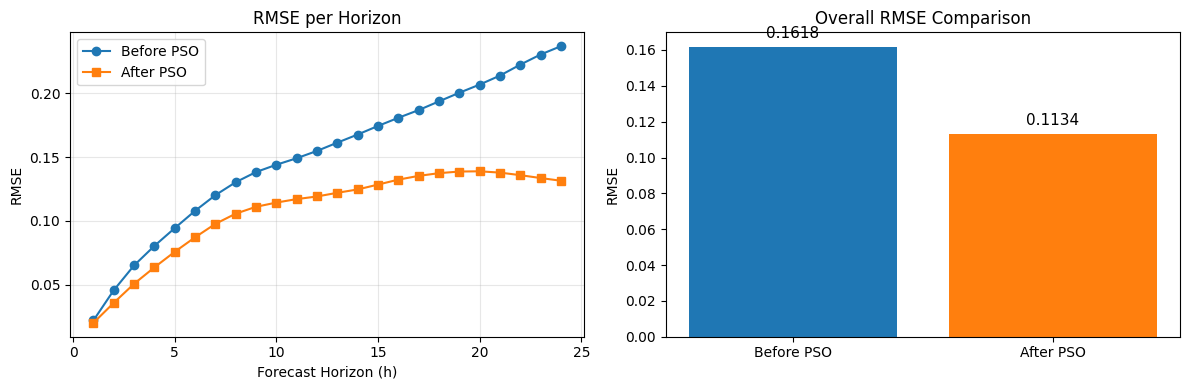

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 按预测步长的 RMSE 曲线
rmse_per_h_before = [np.sqrt(mean_squared_error(y_test[:, h], y_pred_before[:, h])) for h in range(H_NUM)]
rmse_per_h_after = [np.sqrt(mean_squared_error(y_test[:, h], y_pred_after[:, h])) for h in range(H_NUM)]

axes[0].plot(range(1, H_NUM + 1), rmse_per_h_before, 'o-', label='Before PSO', color='C0')
axes[0].plot(range(1, H_NUM + 1), rmse_per_h_after, 's-', label='After PSO', color='C1')
axes[0].set_xlabel('Forecast Horizon (h)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE per Horizon')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 柱状图对比
axes[1].bar(['Before PSO', 'After PSO'], [rmse_before, rmse_after], color=['C0', 'C1'])
axes[1].set_ylabel('RMSE')
axes[1].set_title('Overall RMSE Comparison')
for i, v in enumerate([rmse_before, rmse_after]):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()